# Results plots for synthetic data

In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

import synth_samples
import synth_plot_basics
import synth_finn.io as fio

importlib.reload(synth_samples)
importlib.reload(synth_plot_basics)
importlib.reload(fio)

from synth_samples import DDBSamples, PBSamples

Setup directories

In [2]:
input_dir = Path("../in")
output_dir = Path("../out")
results_dir = output_dir / "synth_results"
image_output_dir = results_dir / "images"

image_output_dir.mkdir(exist_ok=True, parents=True)

Load data

In [3]:
x_train_test, u_train_test = fio.load_synthetic_data("train-test")
x_indis_test, u_indis_test = fio.load_synthetic_data("in-dis-test")

t_full = np.load(input_dir / "synthetic_data/t_full.npy")
u_full = (np.load(input_dir / "synthetic_data/u_full.npy")).T
u_adv = np.load(input_dir / "synthetic_data/u_adv.npy")
true_adv = np.load(input_dir / "synthetic_data/true_adv.npy")

Plot data

/var/folders/3v/jk4_t2254jjf11w2hj0bw9580000gn/T/ipykernel_42231/2482326336.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/stefaniascheurer/Documents/Uni/Promotion/Repos/uq-finn/src/synth_plot_basics.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


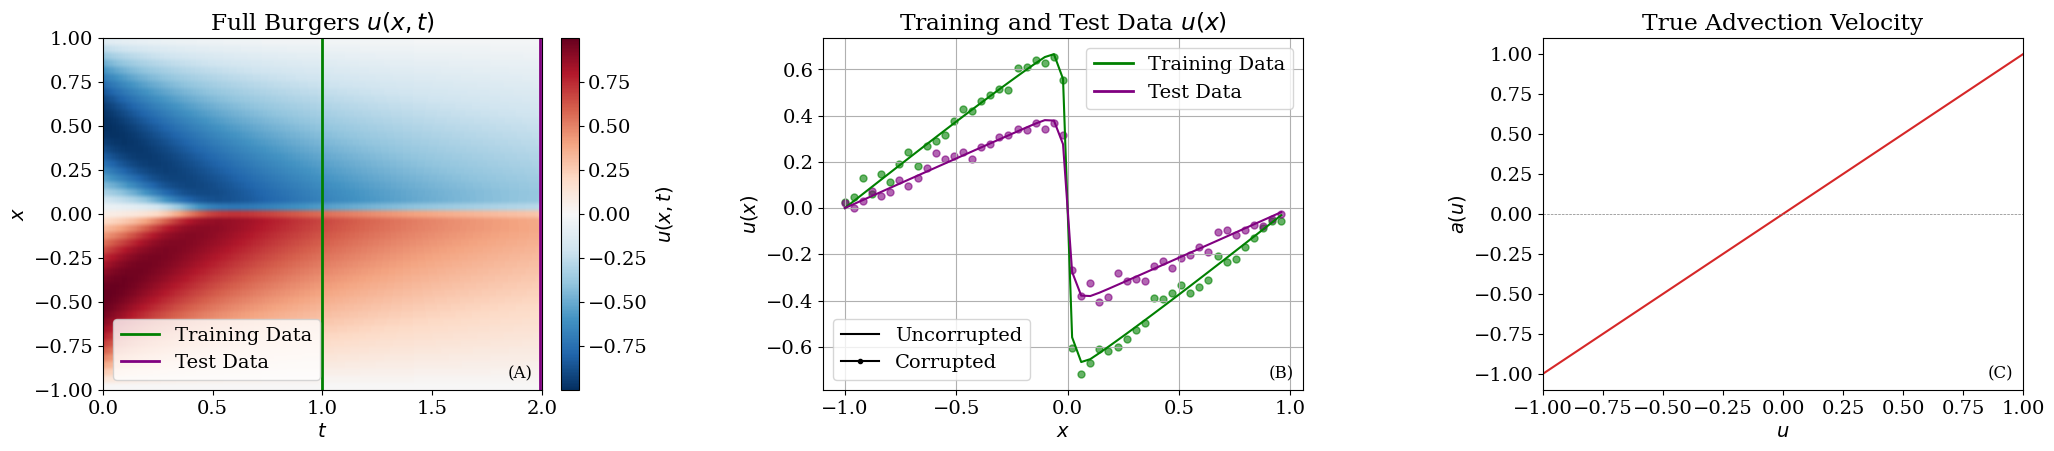

In [4]:
fig, axs = synth_plot_basics.get_axes_for_data()

ax1 = axs[0]
im1 = ax1.imshow(u_full, extent=[0, 2, -1, 1], origin="lower", aspect="auto", cmap="RdBu_r")
ax1.set_title("Full Burgers $u(x, t)$")
ax1.axvline(1.0, color="green", lw=2.0, ls="-", label="Training Data")
ax1.axvline(1.99, color="purple", lw=2.0, ls="-", label="Test Data")
ax1.set_xlabel(r"$t$")
ax1.set_ylabel(r"$x$")
ax1.legend(loc="lower left")
fig.colorbar(im1, ax=ax1, label=r"$u(x, t)$", fraction=0.046, pad=0.04)

ax2 = axs[1]
ax2.plot(x_train_test, u_full[:, 200], color="green", label="Uncorrupted Training Data ($t=1.0$)", lw=1.5)
ax2.scatter(x_train_test, u_train_test, color="green", s=25, label="Training Data", alpha=0.6)
ax2.plot(x_indis_test, u_full[:, -1], color="purple", label="True Test Data ($t=2.0$)", lw=1.5)
ax2.scatter(x_indis_test, u_indis_test, color="purple", s=25, label="Test Data", alpha=0.6)
ax2.set_title("Training and Test Data $u(x)$")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u(x)$")
ax2.grid()
color_handles = [
    Line2D([0], [0], color="green", lw=2, label="Training Data"),
    Line2D([0], [0], color="purple", lw=2, label="Test Data")
]
legend1 = ax2.legend(handles=color_handles, loc="upper right")
ax2.add_artist(legend1)

style_handles = [
    Line2D([0], [0], color="black", linestyle="-", label="Uncorrupted"),
    Line2D([0], [0], color="black", marker=".", label="Corrupted")
]
ax2.legend(handles=style_handles, loc="lower left")


ax3 = axs[2]
ax3.plot(u_adv, true_adv, label="$v(u) = u$", color="C3")
ax3.set_xlabel(r"$u$")
ax3.set_ylabel(r"$a(u)$")
ax3.set_title("True Advection Velocity")
ax3.axhline(0, color="gray", lw=0.5, ls="--")
ax3.set_xlim(-1.0, 1.0)

ax1.text(0.98, 0.02, "(A)", transform=ax1.transAxes, fontsize=12, va="bottom", ha="right")
ax2.text(0.98, 0.02, "(B)", transform=axs[1].transAxes, fontsize=12, va="bottom", ha="right")
ax3.text(0.98, 0.02, "(C)", transform=axs[2].transAxes, fontsize=12, va="bottom", ha="right")

plt.tight_layout()
synth_plot_basics.savefig(fig, image_output_dir / "synth_data")
plt.show()

Load relevant results

In [5]:
datasets = {
    "ddb": DDBSamples.from_dir(results_dir / "synth_ddb"),
    "pb": PBSamples.from_dir(results_dir / "synth_pb"),
}
datasets_list = list(datasets.values())

Bootstrap samples

/var/folders/3v/jk4_t2254jjf11w2hj0bw9580000gn/T/ipykernel_42231/916405200.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/stefaniascheurer/Documents/Uni/Promotion/Repos/uq-finn/src/synth_plot_basics.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


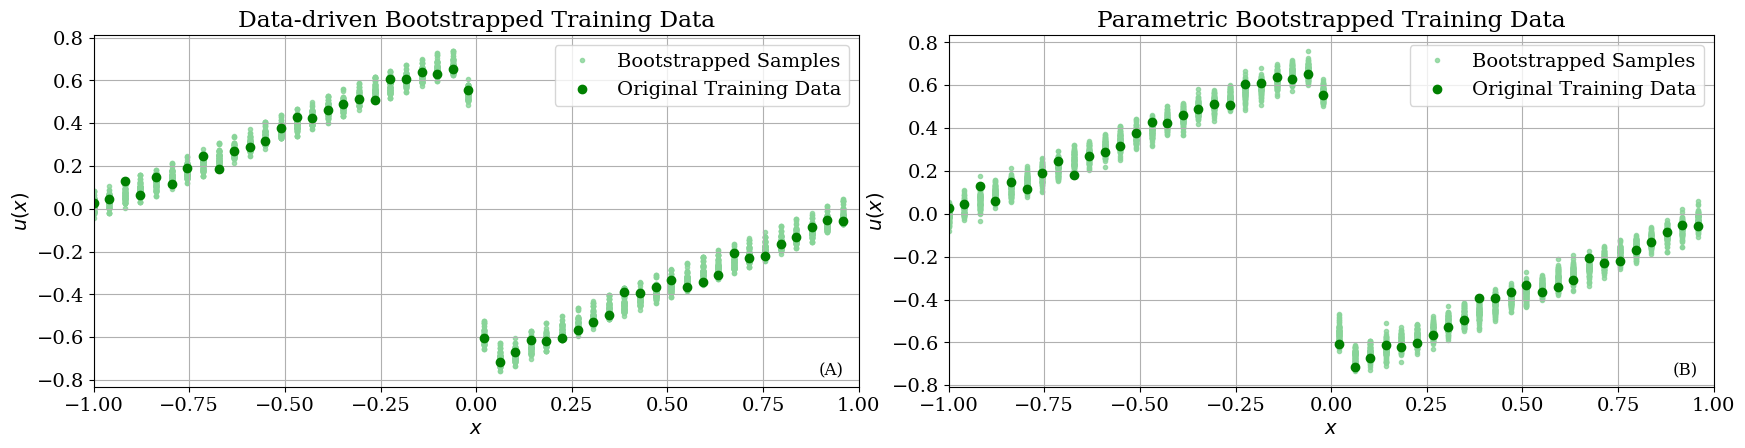

In [6]:
fig, axs = synth_plot_basics.get_axes_for_samples()

ax1 = axs[0]
ax2 = axs[1]
ax1.text(0.98, 0.02, "(A)", transform=ax1.transAxes, fontsize=12, va="bottom", ha="right")
ax2.text(0.98, 0.02, "(B)", transform=axs[1].transAxes, fontsize=12, va="bottom", ha="right")

bootstrap_lines = ax1.plot(x_train_test, datasets["ddb"].mixed_quantiles[:, :], color="#88d498", marker=".", linestyle="None", alpha=0.8, zorder=1, label="Bootstrapped Samples")
data = ax1.scatter(x_train_test, u_train_test, color="green", marker="o", zorder=2, label="Original Training Data")
ax1.set_title("Data-driven Bootstrapped Training Data")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$u(x)$")
ax1.legend(handles=[bootstrap_lines[0], data], loc="upper right")
ax1.grid()
ax1.set_xlim(-1, 1)

bootstrap_lines = ax2.plot(x_train_test, datasets["pb"].bootstraps[:, :], color="#88d498", marker=".", linestyle="None", alpha=0.8, zorder=1, label="Bootstrapped Samples")
data = ax2.scatter(x_train_test, u_train_test, color="green", marker="o", zorder=2, label="Original Training Data")
ax2.set_title("Parametric Bootstrapped Training Data")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u(x)$")
ax2.legend(handles=[bootstrap_lines[0], data], loc="upper right")
ax2.grid()
ax2.set_xlim(-1, 1)

plt.tight_layout()
synth_plot_basics.savefig(fig, image_output_dir / "bootstrap_samples")
plt.show()

DDB vs PB results as samples

TypeError: set_statevar_axes_stuff() missing 1 required positional argument: 'mode'

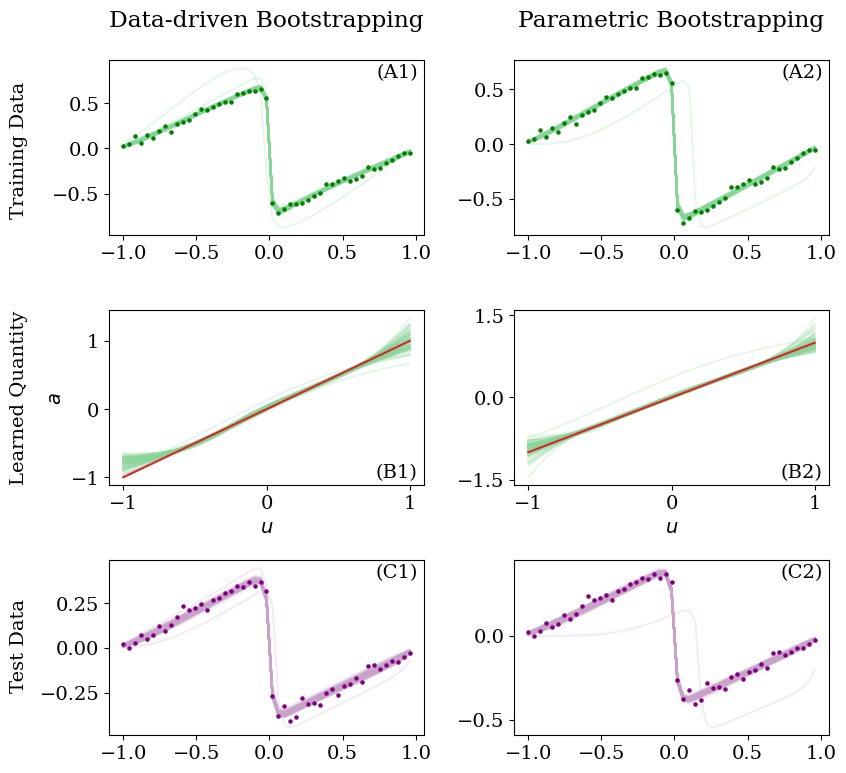

In [7]:
fig, axs = synth_plot_basics.get_axes_for_comparison()

axs[0, 0].plot(x_train_test, datasets["ddb"].u_train_test, color="#88d498", alpha=0.2, linestyle="-", zorder=1)
axs[0, 0].scatter(x_train_test, u_train_test, color="green", marker="o", s=5, zorder=2)
axs[0, 0].set_title("Data-driven Bootstrapping\n")

axs[0, 1].plot(x_train_test, datasets["pb"].u_train_test, color="#88d498", alpha=0.2, linestyle="-", zorder=1)
axs[0, 1].scatter(x_train_test, u_train_test, color="green", marker="o", s=5, zorder=2)
axs[0, 1].set_title("Parametric Bootstrapping\n")

axs[1, 0].plot(datasets["ddb"].learned_x, datasets["ddb"].learned_y, color="#88d498", alpha=0.2, linestyle="-", zorder=1)
axs[1, 0].plot(u_adv, true_adv, color="C3")

axs[1, 1].plot(datasets["pb"].learned_x, datasets["pb"].learned_y, color="#88d498", alpha=0.2, linestyle="-", zorder=1)
axs[1, 1].plot(u_adv, true_adv, color="C3")

axs[2, 0].plot(x_indis_test, datasets["ddb"].u_in_dis_test, color="#C8A2C8", alpha=0.2, linestyle="-", zorder=1)
axs[2, 0].scatter(x_indis_test, u_indis_test, color="purple", marker="o", s=5, zorder=2)

axs[2, 1].plot(x_indis_test, datasets["pb"].u_in_dis_test, color="#C8A2C8", alpha=0.2, linestyle="-", zorder=1)
axs[2, 1].scatter(x_indis_test, u_indis_test, color="purple", marker="o", s=5, zorder=2)

axs[0, 0].text(0.98, 0.98, "(A1)", transform=axs[0, 0].transAxes, fontsize=14, va="top", ha="right")
axs[0, 1].text(0.98, 0.98, "(A2)", transform=axs[0, 1].transAxes, fontsize=14, va="top", ha="right")
axs[1, 0].text(0.98, 0.02, "(B1)", transform=axs[1, 0].transAxes, fontsize=14, va="bottom", ha="right")
axs[1, 1].text(0.98, 0.02, "(B2)", transform=axs[1, 1].transAxes, fontsize=14, va="bottom", ha="right")
axs[2, 0].text(0.98, 0.98, "(C1)", transform=axs[2, 0].transAxes, fontsize=14, va="top", ha="right")
axs[2, 1].text(0.98, 0.98, "(C2)", transform=axs[2, 1].transAxes, fontsize=14, va="top", ha="right")

fig.text(0.0, 0.88, "Training Data", rotation=90, va="center", ha="center", fontsize=14)
fig.text(0.0, 0.55, "Learned Quantity", rotation=90, va="center", ha="center", fontsize=14)
fig.text(0.0, 0.22, "Test Data", rotation=90, va="center", ha="center", fontsize=14)


legend_elements = [
    plt.Line2D([0], [0], linestyle="none", marker=".", color="black", label="Corrupted Data"),
    plt.Line2D([0], [0], linestyle="-", color="black", label="Predicted Samples"),
    plt.Line2D([0], [0], linestyle="-", color="C3", label="True a(u)")
]

synth_plot_basics.set_learned_axes_stuff(axs[1, 0], set_xlabel=True, set_ylabel=True)
synth_plot_basics.set_learned_axes_stuff(axs[1, 1], set_xlabel=True, set_ylabel=False)

synth_plot_basics.set_statevar_axes_stuff(axs[0, 0], set_xlabel=True, set_ylabel=True)
synth_plot_basics.set_statevar_axes_stuff(axs[0, 1], set_xlabel=True, set_ylabel=False)
synth_plot_basics.set_statevar_axes_stuff(axs[2, 0], set_xlabel=True, set_ylabel=True)
synth_plot_basics.set_statevar_axes_stuff(axs[2, 1], set_xlabel=True, set_ylabel=False)

fig.legend(handles=legend_elements, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.075))

plt.tight_layout()
synth_plot_basics.savefig(fig, image_output_dir / "ddb_vs_pb_samples")
plt.show()

DDB vs PB results as CIs

/var/folders/3v/jk4_t2254jjf11w2hj0bw9580000gn/T/ipykernel_42231/515383193.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/stefaniascheurer/Documents/Uni/Promotion/Repos/uq-finn/src/synth_plot_basics.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


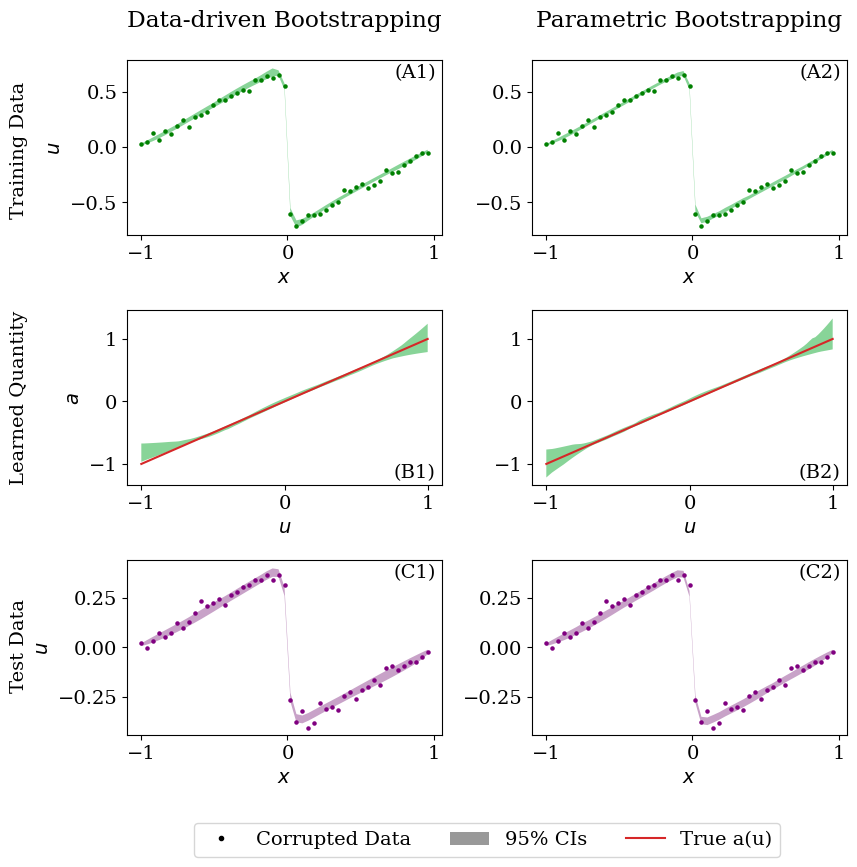

In [11]:
fig, axs = synth_plot_basics.get_axes_for_comparison()

perc = np.percentile(datasets["ddb"].u_train_test, [2.5, 97.5], axis=1)
axs[0, 0].fill_between(x_train_test, *perc, edgecolor="none", facecolor="#88d498", zorder=1)
axs[0, 0].scatter(x_train_test, u_train_test, color="green", marker="o", s=5, zorder=2)
axs[0, 0].set_title("Data-driven Bootstrapping\n")

perc = np.percentile(datasets["pb"].u_train_test, [2.5, 97.5], axis=1)
axs[0, 1].fill_between(x_train_test, *perc, edgecolor="none", facecolor="#88d498", zorder=1)
axs[0, 1].scatter(x_train_test, u_train_test, color="green", marker="o", s=5, zorder=2)
axs[0, 1].set_title("Parametric Bootstrapping\n")

perc = np.percentile(datasets["ddb"].learned_y, [2.5, 97.5], axis=1)
axs[1, 0].fill_between(datasets["ddb"].learned_x.squeeze(), *perc, edgecolor="none", facecolor="#88d498", zorder=1)
axs[1, 0].plot(u_adv, true_adv, color="C3", zorder=2)

perc = np.percentile(datasets["pb"].learned_y, [2.5, 97.5], axis=1)
axs[1, 1].fill_between(datasets["pb"].learned_x.squeeze(), *perc, edgecolor="none", facecolor="#88d498", zorder=1)
axs[1, 1].plot(u_adv, true_adv, color="C3", zorder=2)

perc = np.percentile(datasets["ddb"].u_in_dis_test, [2.5, 97.5], axis=1)
axs[2, 0].fill_between(x_indis_test, *perc, edgecolor="none", facecolor="#C8A2C8", zorder=1)
axs[2, 0].scatter(x_indis_test, u_indis_test, color="purple", marker="o", s=5, zorder=2)

perc = np.percentile(datasets["pb"].u_in_dis_test, [2.5, 97.5], axis=1)
axs[2, 1].fill_between(x_indis_test, *perc, edgecolor="none", facecolor="#C8A2C8", zorder=1)
axs[2, 1].scatter(x_indis_test, u_indis_test, color="purple", marker="o", s=5, zorder=2)

axs[0, 0].text(0.98, 0.98, "(A1)", transform=axs[0, 0].transAxes, fontsize=14, va="top", ha="right")
axs[0, 1].text(0.98, 0.98, "(A2)", transform=axs[0, 1].transAxes, fontsize=14, va="top", ha="right")
axs[1, 0].text(0.98, 0.02, "(B1)", transform=axs[1, 0].transAxes, fontsize=14, va="bottom", ha="right")
axs[1, 1].text(0.98, 0.02, "(B2)", transform=axs[1, 1].transAxes, fontsize=14, va="bottom", ha="right")
axs[2, 0].text(0.98, 0.98, "(C1)", transform=axs[2, 0].transAxes, fontsize=14, va="top", ha="right")
axs[2, 1].text(0.98, 0.98, "(C2)", transform=axs[2, 1].transAxes, fontsize=14, va="top", ha="right")

fig.text(-0.02, 0.88, "Training Data", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.02, 0.55, "Learned Quantity", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.02, 0.22, "Test Data", rotation=90, va="center", ha="center", fontsize=14)


legend_elements = [
    plt.Line2D([0], [0], linestyle="none", marker=".", color="black", label="Corrupted Data"),
    mpatches.Rectangle((0, 0), 1, 1, fc="black", alpha=0.4, label="95% CIs"),
    plt.Line2D([0], [0], linestyle="-", color="C3", label="True a(u)")
]

for i in range(axs.shape[0]):
    row_axes = axs[i, :]
    y_lims = [ax.get_ylim() for ax in row_axes]
    ymin = min(l[0] for l in y_lims)
    ymax = max(l[1] for l in y_lims)
    for ax in row_axes:
        ax.set_ylim(ymin, ymax)

synth_plot_basics.set_learned_axes_stuff(axs[1, 0], set_xlabel=True, set_ylabel=True)
synth_plot_basics.set_learned_axes_stuff(axs[1, 1], set_xlabel=True, set_ylabel=False)

synth_plot_basics.set_statevar_axes_stuff(axs[0, 0], "train", set_xlabel=True, set_ylabel=True)
synth_plot_basics.set_statevar_axes_stuff(axs[0, 1], "train", set_xlabel=True, set_ylabel=False)
synth_plot_basics.set_statevar_axes_stuff(axs[2, 0], "test", set_xlabel=True, set_ylabel=True)
synth_plot_basics.set_statevar_axes_stuff(axs[2, 1], "test", set_xlabel=True, set_ylabel=False)

fig.legend(handles=legend_elements, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.075))

plt.tight_layout()
synth_plot_basics.savefig(fig, image_output_dir / "ddb_vs_pb_intervals")
plt.show()

In [ ]:
ddb_ci_areas = datasets["ddb"].calc_areas()
pb_ci_areas = datasets["pb"].calc_areas()

print("DDB:", ddb_ci_areas)
print("PB:", pb_ci_areas)


DDB: {'u_train_test': np.float64(0.07445115689150222), 'u_in_dis_test': np.float64(0.08054271113545611), 'u_out_dis_test': np.float64(0.07682820396478834), 'learned_y': np.float64(0.20901116063415195)}
PB: {'u_train_test': np.float64(0.06818963387752977), 'u_in_dis_test': np.float64(0.07199254701959386), 'u_out_dis_test': np.float64(0.07222115331424439), 'learned_y': np.float64(0.2233034728046776)}
